In [1]:
!nvidia-smi

Tue Apr 21 13:03:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.20             Driver Version: 580.126.20     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:25:00.0 Off |                    0 |
| N/A   33C    P0             44W /  300W |      14MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
import numpy as np
import torch
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
from utils.utils_correspondence import resize
from model_utils.extractor_hardnet import load_hardnet
from preprocess_map import set_seed
from pathlib import Path
import pandas as pd
from tqdm import tqdm
from utils.my_stuff import *
from sklearn.decomposition import PCA, KernelPCA
import torchvision.transforms.functional as vF
from torchvision.transforms.functional import to_tensor
import glob
import pandas as pd
from itertools import product
import pickle
from dataclasses import dataclass
import random
from scipy.spatial import Delaunay, delaunay_plot_2d
import networkx as nx
from kornia.morphology import closing

# from segmentation import segmentation

In [3]:
data_path = Path('../data/SealID')
full_images = data_path / 'full images'
df = pd.read_csv(full_images / 'annotation.csv')
annotations = dict(list(df.groupby('class_id')))
for key in annotations:
    annotations[key] = dict(list(annotations[key].groupby('reid_split')))

query_imgs = sorted(glob.glob('../data/SealID/full images/source_query/*.jpg'))
database_imgs = sorted(glob.glob('../data/SealID/full images/source_database/*.jpg'))

lookup = dict(list(df.groupby('reid_split')))

lookup_qr = {}
for _, (file, class_id) in lookup['query'][['file', 'class_id']].iterrows():
    lookup_qr[file[:-4]] = class_id

lookup_db = {}
for _, (file, class_id) in lookup['database'][['file', 'class_id']].iterrows():
    lookup_db[file[:-4]] = class_id

In [4]:
annotations

{1: {'database':    class_id        file reid_split segmentation_split
  0         1  fxhdev.jpg   database           training
  1         1  lhczmz.jpg   database           training
  2         1  nhcykn.jpg   database           training
  3         1  xpmkjw.jpg   database           training
  4         1  qcsyyu.jpg   database           training
  5         1  gwpdve.jpg   database            testing
  6         1  nmjxdr.jpg   database            testing
  7         1  lphfsr.jpg   database            testing,
  'query':      class_id        file reid_split segmentation_split
  430         1  wlbagw.jpg      query           training
  431         1  meoqtw.jpg      query           training
  432         1  tvzubb.jpg      query           training
  433         1  ggbxhv.jpg      query         validation
  434         1  ebwolt.jpg      query            testing},
 3: {'database':     class_id        file reid_split segmentation_split
  8          3  gwldkl.jpg   database           t

In [11]:
%matplotlib inline

img1_path = query_imgs[2]
img2_path = database_imgs[9]

print(img1_path, img2_path)
visualize_pair(img1_path, img2_path, figsize=(8, 8))

../data/SealID/full images/source_query/abecjl.jpg ../data/SealID/full images/source_database/aodsxw.jpg


FileNotFoundError: [Errno 2] No such file or directory: '../data/SealID/full images/source_query/abecjl.pt'

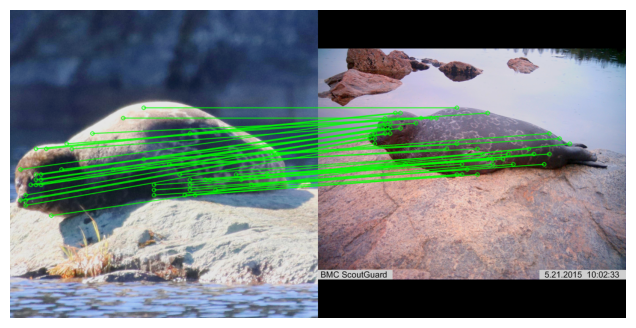

In [15]:
%matplotlib inline

# img1_path = files[1]
# img2_path = files[171]

visualize_matches(img1_path, img2_path, target_res=60, num_matches=100, figsize=(8, 4))

In [ ]:
def fun(path):
    desc, mask = prepare_image(path, 60)
    desc, mask = desc.cpu(), mask.cpu()
    return extract_features(desc, mask)

data = list(map(fun, tqdm(lookup.keys())))

features, idxs = zip(*data)
X = torch.cat(features).double().numpy()
X.shape

from sklearn.cluster import KMeans

kmeans = KMeans(128, verbose=True, max_iter=1000, tol=1e-6).fit(X)
X_hat = kmeans.cluster_centers_

# pca = KernelPCA(3, kernel='rbf').fit(X_hat)
pca = PCA(3, svd_solver='full').fit(X)

palette = pca.transform(X)
c_min, c_max = palette.min(), palette.max()

def visualize(img_path, target_res=60, figsize=(6, 3)):

    desc, mask = prepare_image(img_path, target_res=target_res)
    torch.cuda.empty_cache()

    f, i = extract_features(desc, mask)

    x = f.cpu().double().numpy()
    # x = X_hat[kmeans.predict(x)]
    colors = pca.transform(x)
    colors = (colors - c_min) / (c_max - c_min)
    # colors /= np.linalg.norm(colors, axis=1, keepdims=True)

    i = tuple(map(lambda x: x.cpu().numpy(), i))
    seg = np.zeros((target_res, target_res, 3))
    seg[i] = colors
    seg = torch.tensor(seg).permute(2, 0, 1).unsqueeze(0)
    seg = F.interpolate(seg, (240, 240), mode='nearest').squeeze(0)
    seg = seg.mul(255).permute(1, 2, 0).numpy().astype(np.uint8)

    img = np.array(resize(Image.open(img_path), 240))
    seg = np.array(seg)

    path = img_path.replace('.jpg', '_map.jpg')
    res = np.hstack((img, seg))
    res = res[(res.sum(1) > 0).all(1)]
    res = Image.fromarray(res)
    # res.save(path)
    return res

In [22]:
with open('matches.pkl', 'rb') as buf:
    matches = pickle.load(buf)

In [63]:
hardnet = load_hardnet('./third_party/hardnet/pretrained/pretrained_all_datasets/HardNet++.pth').eval()
hardnet.to('cuda')

/home/veikka_immonen/GeoAware-SC/model_utils/extractor_hardnet.py:63: UserWarning: nn.init.orthogonal is now deprecated in favor of nn.init.orthogonal_.
  nn.init.orthogonal(m.weight.data, gain=0.6)


HardNet(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (11): ReLU()
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (14): R

In [18]:
books = glob.glob('../data/SealID/graphs/*.pt')
len(books)

1650

'fdsjklöjklö'

In [19]:
from torch_geometric.data import Batch, Dataset
from torch_geometric.loader import DataLoader


def zip_graphbook(book):
    keys, query, database = [], [], []
    for key, val in book.items():
        keys.append(key)
        query.append(val['query'])
        database.append(val['database'])
    return {'key': keys, 'query': query, 'database': database}


class BookSet(Dataset):
    def __init__(self, root, transform=None, pre_transform=None,
                 pre_filter=None, log = True, force_reload=False):
        super().__init__(root, transform, pre_transform, pre_filter, log, force_reload)
        self.book_files = glob.glob(root.rstrip('/') + '/*.pt')
    def len(self):
        return len(self.book_files)
    def get(self, idx):
        file = self.book_files[idx]
        book = torch.load(file)
        name = file.rsplit('graphbook_', 1)[-1][:-3]
        return name, zip_graphbook(book)

bookset = BookSet('../data/SealID/graphs')


In [ ]:
import torch
from torch import nn
from torch_geometric.utils import add_self_loops, degree
from torch_geometric.nn import MessagePassing, global_max_pool, global_mean_pool


def operate_spatial(batch):
    yx = batch.yx
    centers = global_mean_pool(yx,  batch.batch)
    yx -= centers[batch.batch]
    norm = yx.norm(dim=1, keepdim=True)
    mag = global_max_pool(norm, batch.batch)
    return yx.div(mag[batch.batch])


class HardNetMultiChannel(nn.Module):

    def __init__(self, path):
        super().__init__()
        self.hardnet = load_hardnet(path)

    def forward(self, x): # x=[0,255]^(B,C,32,32)
        shape = x.shape
        x = x.view(-1, 1, *shape[2:]).float().div(255)
        x = self.hardnet(x).view(*shape[:2], -1)
        x = F.adaptive_avg_pool1d(x.transpose(1, 2), 1).squeeze(-1)
        return x


class NodeAggregator(MessagePassing):

    def __init__(self, aggr='sum'):
        super().__init__(aggr=aggr)

    def forward(self, x, edge_index, hops=2):
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))
        row, col = edge_index
        deg = degree(col, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        norm = (deg_inv_sqrt[row] * deg_inv_sqrt[col]).view(-1, 1)
        for _ in range(hops):
            x = self.propagate(edge_index, x=x, norm=norm)
        return x

    def message(self, x_j, norm):
        return x_j * norm


class GraphAggregator(nn.Module):

    def __init__(self, aggr='sum'):
        super().__init__()
        self.net = HardNetMultiChannel('./third_party/hardnet/pretrained/pretrained_all_datasets/HardNet++.pth')
        self.node_aggregator = NodeAggregator(aggr='sum') 

    def forward(self, batch, k=2, pool='max'):
        patches = self.net(batch.patch)
        spatial = operate_spatial(batch)
        x = torch.cat((patches, spatial), dim=1)
        e = batch.edge_index
        b = batch.batch
        y = self.node_aggregator(x, e, k)
        if pool == 'max':
            return global_max_pool(y, b)
        elif pool == 'mean':
            return global_mean_pool(y, b)
        else:
            raise NotImplementedError

model = GraphAggregator().eval().to('cuda')


/home/veikka_immonen/GeoAware-SC/model_utils/extractor_hardnet.py:63: UserWarning: nn.init.orthogonal is now deprecated in favor of nn.init.orthogonal_.
  nn.init.orthogonal(m.weight.data, gain=0.6)


In [9]:
name, book = bookset[0]
loader = DataLoader(book['query'], batch_size=32)
batch = next(iter(loader)).to('cuda')
print(name)

with torch.inference_mode():
    foo = model(batch, k=3)

foo.norm(dim=1)

fytoxg


tensor([0.6493, 0.6927, 0.8240, 0.5962, 0.6888, 0.5222, 0.9989, 0.4785, 0.7413,
        0.6895, 0.6282, 0.7709, 0.7847, 0.6888, 0.6714, 0.6445, 0.7458, 0.6122,
        0.7885, 0.5891, 0.7744, 0.6942, 0.7768, 0.6160, 0.6132, 0.8113, 0.7483,
        0.6476, 0.8169, 0.7253, 0.8979, 0.6448], device='cuda:0',
       dtype=torch.float64)

In [10]:
bookset.book_files

['../data/SealID/graphs/graphbook_fytoxg.pt',
 '../data/SealID/graphs/graphbook_gqtrpb.pt',
 '../data/SealID/graphs/graphbook_gparyw.pt',
 '../data/SealID/graphs/graphbook_hqddng.pt',
 '../data/SealID/graphs/graphbook_ebkbms.pt',
 '../data/SealID/graphs/graphbook_dbcxyt.pt',
 '../data/SealID/graphs/graphbook_caibjy.pt',
 '../data/SealID/graphs/graphbook_eutapc.pt',
 '../data/SealID/graphs/graphbook_ieltfl.pt',
 '../data/SealID/graphs/graphbook_ayvefe.pt',
 '../data/SealID/graphs/graphbook_ddgors.pt',
 '../data/SealID/graphs/graphbook_cwuivi.pt',
 '../data/SealID/graphs/graphbook_agpury.pt',
 '../data/SealID/graphs/graphbook_kvexwz.pt',
 '../data/SealID/graphs/graphbook_kcsbpk.pt',
 '../data/SealID/graphs/graphbook_jvkwkd.pt',
 '../data/SealID/graphs/graphbook_flidwx.pt',
 '../data/SealID/graphs/graphbook_lkyplr.pt',
 '../data/SealID/graphs/graphbook_ihcbfm.pt',
 '../data/SealID/graphs/graphbook_hwqnow.pt',
 '../data/SealID/graphs/graphbook_lwweme.pt',
 '../data/SealID/graphs/graphbook_

In [21]:
@torch.inference_mode()
def test_sample(sample, model, lookup_qr, lookup_db):

    query, book = sample

    candidates = book['key']
    G_q = book['query']
    G_d = book['database']

    loader_q = DataLoader(G_q, batch_size=32)
    loader_d = DataLoader(G_d, batch_size=32)

    f_q = torch.cat([model(batch.to('cuda'), k=5) for batch in loader_q])
    f_d = torch.cat([model(batch.to('cuda'), k=5) for batch in loader_d])

    f_q = F.normalize(f_q).unsqueeze(1)
    f_d = F.normalize(f_d).unsqueeze(1)
    
    logits = f_q @ f_d.transpose(1, 2)
    logits = logits.flatten(0)

    res = candidates[logits.argmax().item()]
    res = lookup_db[res]
    true = lookup_qr[query]

    return res, true


results = [test_sample(sample, model, lookup_qr, lookup_db) for sample in tqdm(bookset)]

100%|██████████| 1650/1650 [14:50<00:00,  1.85it/s]


In [25]:
pred, true = np.array(results).T
(pred == true).mean()

0.283030303030303

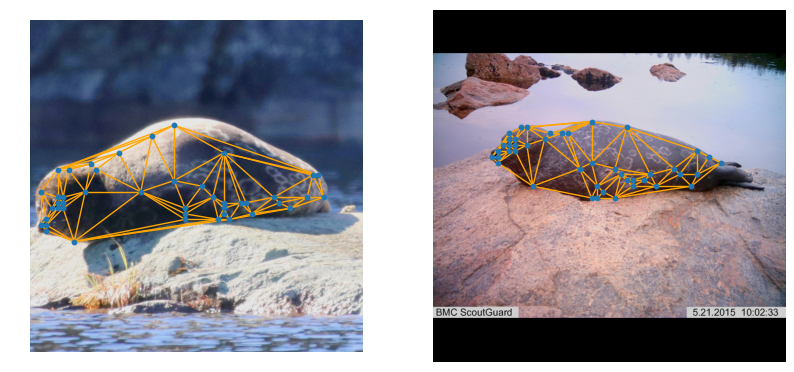

In [3]:
from torch_geometric.utils import to_networkx

path_query = query_imgs[2]
path_database = database_imgs[9]

query = path_query.rsplit('/', 1)[-1][:-4]
database = path_database.rsplit('/', 1)[-1][:-4]

graphs = torch.load(f'../data/SealID/graphs/graphbook_{query}.pt')[database]

G_q = to_networkx(graphs['query']).to_undirected()
G_d = to_networkx(graphs['database']).to_undirected()

xy_q = dict(zip(range(len(graphs['query'].yx)), graphs['query'].yx.roll(1, 1).numpy() * 10))
xy_d = dict(zip(range(len(graphs['database'].yx)), graphs['database'].yx.roll(1, 1).numpy() * 10))

img_query = resize(Image.open(path_query), 600)
img_database = resize(Image.open(path_database), 600)

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img_query)
ax2.imshow(img_database)

nx.draw(G_q, pos=xy_q, ax=ax1, node_size=10, edge_color='orange')
nx.draw(G_d, pos=xy_d, ax=ax2, node_size=10, edge_color='orange')

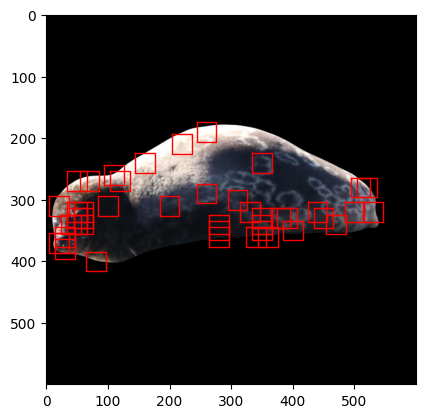

In [79]:
img = resize(Image.open(path_query.replace('source', 'segmented')), 600)
xy = np.stack(list(xy_q.values())) - 16

plt.imshow(img)

for x, y in xy:
    plt.plot([x, x+32, x+32, x, x], [y, y, y+32, y+32, y], 'r', linewidth=1)


In [ ]:
from model_utils.extractor_sd import load_model, process_features_and_mask
from model_utils.extractor_dino import ViTExtractor
from model_utils.projection_network import AggregationNetwork


# load the pretrained weights
num_patches = 60
set_seed()
sd_model, sd_aug = load_model(diffusion_ver='v1-5', image_size=num_patches*16, num_timesteps=50)
extractor_vit = ViTExtractor('dinov2_vitb14', stride=14, device='cuda')
aggre_net = AggregationNetwork(feature_dims=[640,1280,1280,768], projection_dim=768, device='cuda')
aggre_net.load_pretrained_weights(torch.load('results_spair/best_856.PTH'))

sd_model.eval()
aggre_net.eval()

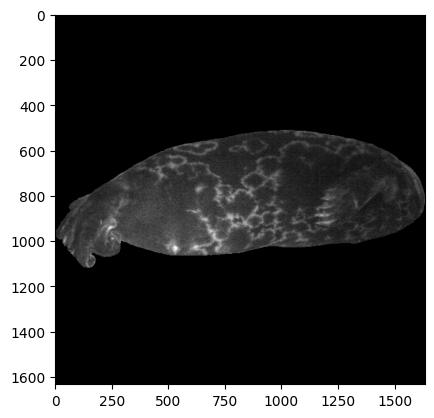

In [36]:
import torchvision

images = sorted(glob.glob("../data/images_original_segmented/*.png"))
img_path = images[11]

img = Image.open(img_path)
img = resize(img, target_res=max(img.size), resize=True, to_pil=True)
x = to_tensor(img).cuda()
mask = x.norm(dim=0, keepdim=True) > 0
# kernel = torch.tensor(create_circular_mask(5)).float().cuda()
# mask = closing(mask.unsqueeze(0), kernel)
plt.imshow(vF.resize(mask.unsqueeze(0), 256, interpolation=torchvision.transforms.InterpolationMode.NEAREST)[0, 0].cpu())
plt.imshow(x.permute(1, 2, 0).cpu())

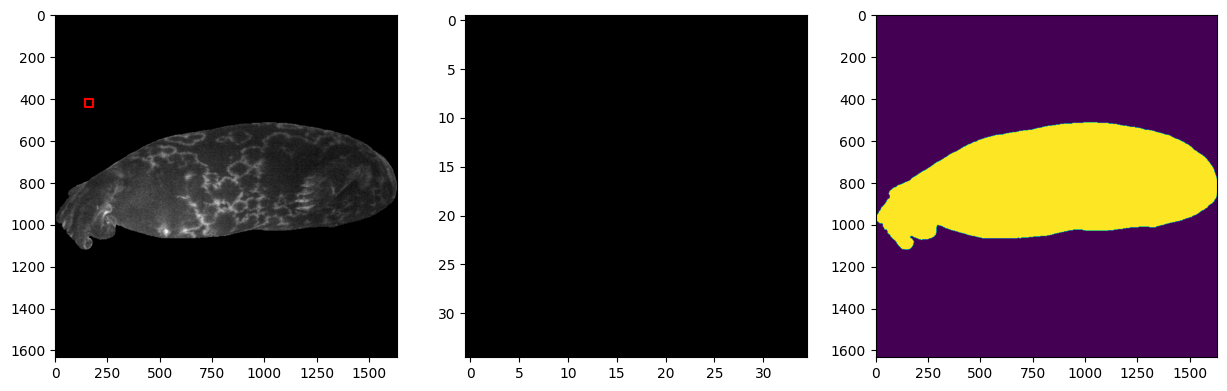

In [ ]:
# img_path = query_imgs[5]
# img_path = query_imgs[3]
img_path = images[11]
img = Image.open(img_path)
img = resize(img, target_res=max(img.size))
img = to_tensor(img).unsqueeze(0).cuda()

kernel_open = torch.tensor(create_circular_mask(5)).float().cuda()
kernel_close = torch.tensor(create_circular_mask(9)).float().cuda()
img_open = opening(img, kernel_open)
img_open = img.clone()

mask = (img_open.norm(dim=1, keepdim=True) > 0).float()
mask = closing(mask, kernel_close)


# _, ax = plt.subplots(1, 3, figsize=(15, 5))
# ax[0].imshow(img)
# ax[1].imshow(img_m.cpu().permute(1, 2, 0))
# ax[2].imshow(mask.cpu()[0, 0])

# _, ax = plt.subplots(1, 3, figsize=(15, 5))
# ax[0].imshow(img_s.permute(1, 2, 0))
# ax[1].imshow(mask_s.cpu())
# ax[2].imshow(img_ms.cpu().permute(1, 2, 0))

_, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img.cpu()[0].permute(1, 2, 0))
ax[0].plot([145, 145, 180, 180, 145], [400, 435, 435, 400, 400], 'r')
ax[1].imshow(crop(img, 400, 145, 35, 35)[0].cpu().permute(1, 2, 0))
ax[2].imshow(mask[0, 0].cpu())

# plt.figure()
# foo = F.interpolate(mask_s.unsqueeze(0).unsqueeze(0), 60, mode='nearest')
# plt.imshow(foo.squeeze(0).squeeze(0).cpu())


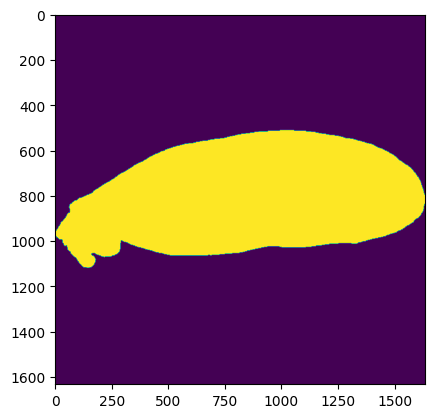

In [30]:
img_m.shape
foo = (~(img_m == 0)).all(1).unsqueeze(0).float()
plt.imshow(foo[0, 0].cpu())

In [31]:
from torchvision.transforms.functional import to_pil_image

In [82]:
features_sd.keys(), features_sd["s3"].shape, desc.shape

(dict_keys(['s2', 's3', 's4', 's5']),
 torch.Size([1, 640, 60, 60]),
 torch.Size([1, 768, 60, 60]))

In [77]:
def sparsify(feature_map, mask_orig):
    dim = feature_map.shape[-2:]
    mask = F.interpolate(mask_orig, size=dim, mode='nearest')[0, 0]
    y, x = torch.where(~mask.bool())
    feature_map[0, :, y, x] = 0
    return feature_map.to_sparse().cpu()

sparsify(features_dino.clone(), mask)

tensor(indices=tensor([[  0,   0,   0,  ...,   0,   0,   0],
                       [  0,   0,   0,  ..., 767, 767, 767],
                       [ 19,  19,  19,  ...,  40,  40,  41],
                       [ 35,  36,  37,  ...,   5,   6,   5]]),
       values=tensor([ 1.3142,  0.9188,  1.2344,  ..., -0.1120, -0.5862,
                      -2.6640]),
       size=(1, 768, 60, 60), nnz=696576, layout=torch.sparse_coo)

In [41]:
mask = mask[0, 0]
img = to_pil_image(img[0])

with torch.inference_mode():
    # extract stable diffusion features
    img_sd_input = resize(img, target_res=num_patches*16, resize=True, to_pil=True)
    features_sd = process_features_and_mask(sd_model, sd_aug, img_sd_input, mask=False, raw=True)
    # del features_sd['s2']

    # extract dinov2 features
    img_dino_input = resize(img, target_res=num_patches*14, resize=True, to_pil=True)
    img_batch = (extractor_vit.preprocess_pil(img_dino_input)).cuda()
    features_dino = extractor_vit.extract_descriptors(img_batch, layer=11, facet='token')
    features_dino = features_dino.permute(0, 1, 3, 2).reshape(1, -1, num_patches, num_patches)

    # aggregate the features and apply post-processing
    desc_gathered = torch.cat([
            features_sd['s3'],
            F.interpolate(features_sd['s4'], size=(num_patches, num_patches), mode='bilinear', align_corners=False),
            F.interpolate(features_sd['s5'], size=(num_patches, num_patches), mode='bilinear', align_corners=False),
            features_dino], dim=1)
    desc = aggre_net(desc_gathered) # 1, 768, 60, 60

In [4]:
files = glob.glob("../data/images_original_source/*.pt")
files

['../data/images_original_source/phs428__63ca9817-995e-4de4-8b2a-700dbb97faee-halfpage.segmented.pt',
 '../data/images_original_source/phs238__19.pt',
 '../data/images_original_source/phs204__43fe7ab4-c21e-3d14-90dc-7bff5da566c8.pt',
 '../data/images_original_source/phs080__1ef399b3-af9c-42f9-ab89-6be025935392.pt',
 '../data/images_original_source/phs164__29.pt',
 '../data/images_original_source/phs383__34f6cf1b-d747-4a62-9d1e-5c3fb0010699.pt',
 '../data/images_original_source/phs142__15.pt',
 '../data/images_original_source/phs388__84cdc358-cb23-4227-aee9-71c457290fb1.pt',
 '../data/images_original_source/phs341__c3b092b7-f2de-4b7b-acb3-0e6e54cb50b8.pt',
 '../data/images_original_source/phs205__e3eaa859-de85-40a7-a07c-3092b0aa36c9.pt',
 '../data/images_original_source/phs044__6.pt',
 '../data/images_original_source/phs083__347255b4-2915-4295-9d48-32e10a047e1d.pt',
 '../data/images_original_source/phs291__7.pt',
 '../data/images_original_source/phs080__4166203b-58d3-47da-b362-b0d006d30

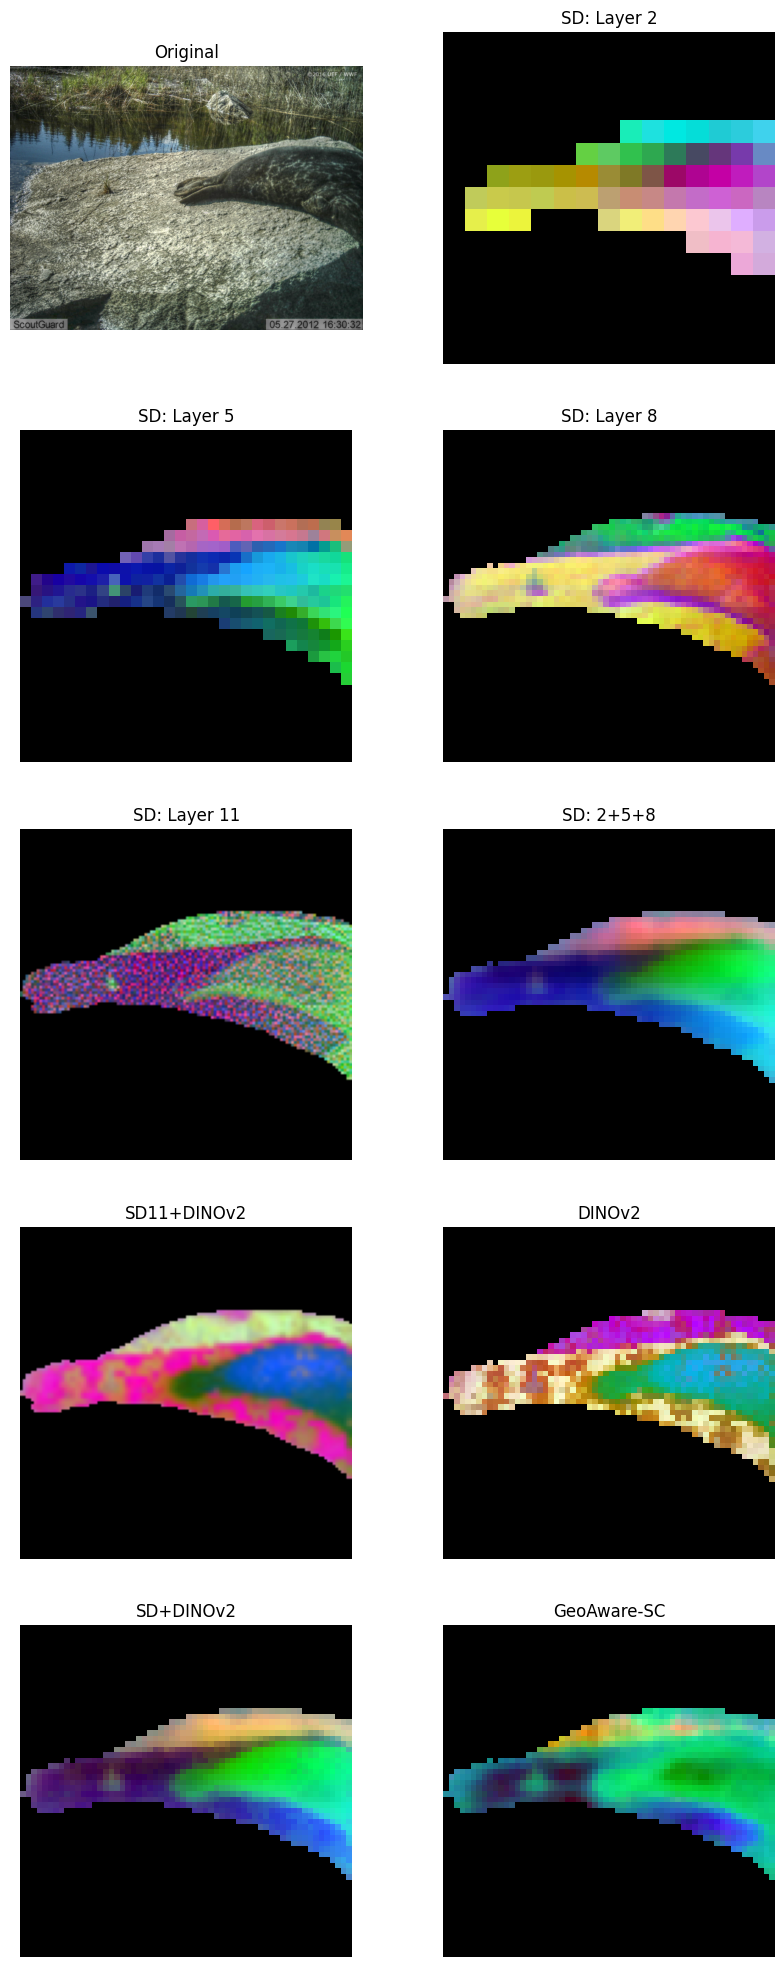

In [7]:
from itertools import chain
import glob
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image


# modify
files = sorted(glob.glob("../data/images_original_source/*.pt"))
ix = 0


raw = torch.load(files[ix])
features_sd = raw["sd"]
for key in features_sd:
    features_sd[key] = features_sd[key].to_dense()
features_dino = raw["dino"].to_dense()
desc = raw["geo"].to_dense()
desc /= desc.norm(1, keepdim=True)
num_patches = 60

img = Image.open(files[ix].replace("pt", "png"))

_, axes = plt.subplots(5, 2, figsize=(10, 25))
axes = list(chain(*axes))
axes[0].set_axis_off()
axes[0].imshow(img)
axes[0].set_title(f'Original')

layers = {
    's2': 'Layer 11',
    's3': 'Layer 8',
    's4': 'Layer 5',
    's5': 'Layer 2',
}

def visualize_map_svd(ax, feat, title=None):
    mask = feat.abs().sum(1) != 0
    ix = mask.nonzero(as_tuple=False)
    vectors = feat[ix[:, 0], :, ix[:, 1], ix[:, 2]]
    mean = vectors.mean(0, keepdim=True)
    X = vectors - mean
    U, S, Vt = torch.linalg.svd(X, full_matrices=False)
    components = Vt[:3]
    proj = X @ components.T
    proj_min = proj.min(dim=0, keepdim=True)[0]
    proj_max = proj.max(dim=0, keepdim=True)[0]
    rgb_vals = (proj - proj_min) / (proj_max - proj_min + 1e-8)
    _, _, W, H = feat.shape
    rgb_image = torch.zeros(W, H, 3)
    rgb_image[ix[:, 1], ix[:, 2]] = rgb_vals
    ax.set_axis_off()
    ax.imshow(rgb_image)
    if title: ax.set_title(title)

for ax, (key, feat) in zip(axes[1:], reversed(features_sd.items())):
    visualize_map_svd(ax, feat, f'SD: {layers[key]}')


feat = torch.cat([
    features_sd['s3'],
    F.interpolate(features_sd['s4'], size=(num_patches, num_patches), mode='bilinear', align_corners=False),
    F.interpolate(features_sd['s5'], size=(num_patches, num_patches), mode='bilinear', align_corners=False),
], dim=1)
mask = features_sd['s3'].abs().sum(1) == 0
ix = mask.nonzero(as_tuple=False)
feat[ix[:, 0], :, ix[:, 1], ix[:, 2]] = 0
visualize_map_svd(axes[5], feat, f'SD: 2+5+8')


feat = torch.cat([
    features_sd['s2'],
    F.interpolate(features_dino, size=num_patches*2, mode='bilinear', align_corners=False),
], dim=1)
mask = features_sd['s2'].abs().sum(1) == 0
ix = mask.nonzero(as_tuple=False)
feat[ix[:, 0], :, ix[:, 1], ix[:, 2]] = 0
visualize_map_svd(axes[6], feat, f'SD11+DINOv2')


visualize_map_svd(axes[7], features_dino, f'DINOv2')


feat = torch.cat([
    features_sd['s3'],
    F.interpolate(features_sd['s4'], size=(num_patches, num_patches), mode='bilinear', align_corners=False),
    F.interpolate(features_sd['s5'], size=(num_patches, num_patches), mode='bilinear', align_corners=False),
    features_dino
], dim=1)
mask = features_sd['s3'].abs().sum(1) == 0
ix = mask.nonzero(as_tuple=False)
feat[ix[:, 0], :, ix[:, 1], ix[:, 2]] = 0
visualize_map_svd(axes[8], feat, f'SD+DINOv2')


visualize_map_svd(axes[9], desc, f'GeoAware-SC')
plt.show()

In [ ]:
(features_sd['s3'].abs().sum(1, keepdim=True) == 0).shape

torch.Size([1, 1, 60, 60])

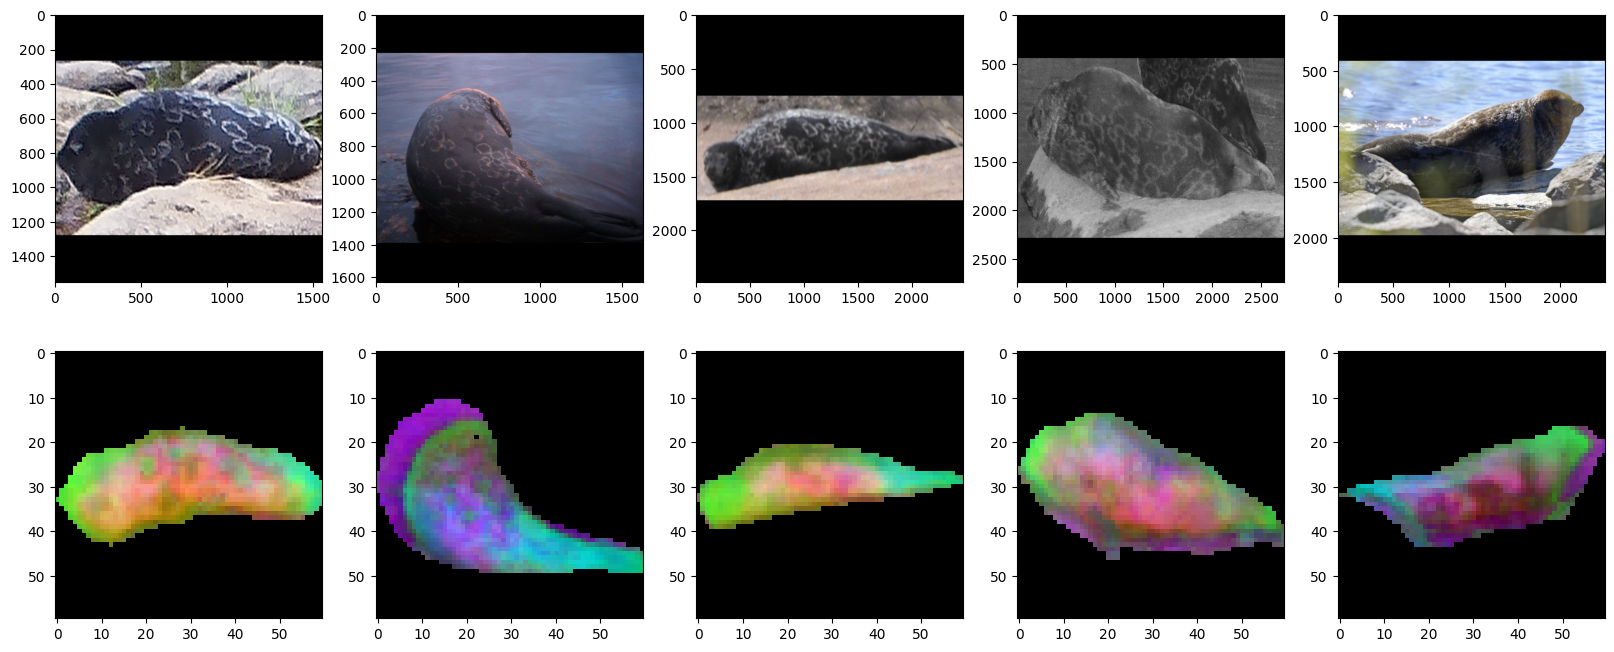

In [9]:
from itertools import chain
import glob
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
from PIL import Image
from utils.utils_correspondence import resize

# modify
seed = 0
n = 5
random.seed(seed)
files = sorted(glob.glob("../data/images_original_source/*.pt"))

selected = random.sample(files, n)
features = list(map(torch.load, selected))
feat = torch.cat([f["geo"].to_dense() for f in features])
feat /= (feat.norm(dim=1, keepdim=True) + 1e-8)
mask = feat.abs().sum(1) != 0
ix = mask.nonzero(as_tuple=False)
vectors = feat[ix[:, 0], :, ix[:, 1], ix[:, 2]]
mean = vectors.mean(0, keepdim=True)
X = vectors - mean
U, S, Vt = torch.linalg.svd(X, full_matrices=False)
components = Vt[:3]
proj = X @ components.T
proj_min = proj.min(dim=0, keepdim=True)[0]
proj_max = proj.max(dim=0, keepdim=True)[0]
rgb_vals = (proj - proj_min) / (proj_max - proj_min + 1e-8)
B, _, W, H = feat.shape
rgb_images = torch.zeros(B, W, H, 3)
rgb_images[ix[:, 0], ix[:, 1], ix[:, 2]] = rgb_vals

_, axes = plt.subplots(2, n, figsize=(4*n, 8))

for file, rgb, (ax1, ax2) in zip(selected, rgb_images, zip(*axes)):
    img = Image.open(file.replace(".pt", ".png"))
    img = resize(img, target_res=max(img.size))
    ax1.imshow(img)
    ax2.imshow(rgb)

plt.show()

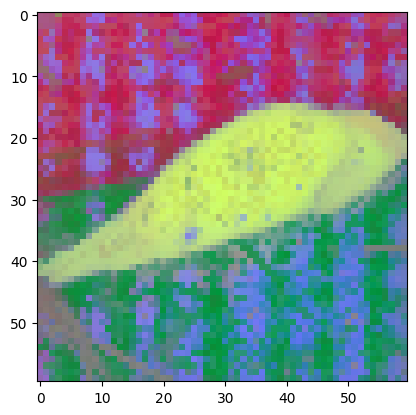

In [32]:
vec = normalize(features_dino)[0, :].flatten(1).t().cpu().numpy()
vec = torch.tensor(PCA(n_components=3).fit_transform(vec)).cuda()
vec = (vec - vec.min()) / (vec.max() - vec.min())
canvas = vec.reshape(60, 60, 3)
plt.imshow(canvas[:, :].cpu())

In [33]:
def get_dinos(path):
    img = Image.open(path)
    with torch.inference_mode():
        img_dino_input = resize(img, target_res=num_patches*14, resize=True, to_pil=True, edge=False)
        img_batch = (extractor_vit.preprocess_pil(img_dino_input)).cuda()
        features_dino = extractor_vit.extract_descriptors(img_batch, layer=11, facet='token')
        features_dino = features_dino.permute(0, 1, 3, 2).reshape(1, -1, num_patches, num_patches)
    return features_dino

all_features = list(map(get_dinos, tqdm(database_imgs)))
torch.cuda.empty_cache()


100%|██████████| 430/430 [00:50<00:00,  8.52it/s]


In [43]:
all_features[0].shape

torch.Size([1, 768, 60, 60])

In [34]:
from torch_pca import PCA

features = torch.cat(all_features).flatten(2).permute(1, 0, 2).flatten(1).t()
print(features.shape)
pca = PCA(3).fit(normalize(features))
pca.__dict__

torch.Size([1548000, 768])


{'components_': tensor([[-0.0375, -0.0039,  0.0095,  ...,  0.0420,  0.0046, -0.0440],
         [ 0.0097,  0.0226, -0.0049,  ...,  0.0230,  0.0004, -0.0157],
         [ 0.0088,  0.0179, -0.0380,  ..., -0.0142,  0.0503,  0.0258]],
        device='cuda:0'),
 'explained_variance_': tensor([0.0790, 0.0543, 0.0434], device='cuda:0'),
 'explained_variance_ratio_': tensor([0.1162, 0.0799, 0.0637], device='cuda:0'),
 'mean_': tensor([[ 1.3837e-02, -2.2259e-03, -1.4995e-02, -1.0328e-02,  1.2803e-02,
          -4.1143e-03,  2.3270e-03, -4.0907e-02,  1.1355e-02,  1.0977e-02,
           3.3789e-02,  1.0547e-03,  1.7410e-03,  1.6791e-02, -4.7391e-03,
          -3.7735e-03, -8.1177e-03,  1.3020e-02,  3.9115e-03,  1.9437e-02,
          -5.5347e-03, -2.4652e-03, -1.3944e-02,  2.8229e-03, -3.3905e-03,
          -6.1442e-03,  4.1529e-02, -2.4786e-02,  2.0381e-02,  8.6343e-03,
           1.0378e-03, -1.9723e-02, -1.7013e-02,  1.2300e-02, -2.1490e-02,
          -2.2689e-02, -1.4721e-02,  6.3626e-03,  3.212

In [35]:
query_features = list(map(get_dinos, tqdm(query_imgs)))
torch.cuda.empty_cache()

  7%|▋         | 109/1650 [00:11<02:44,  9.38it/s]


KeyboardInterrupt: 

torch.Size([1, 768, 960, 960])


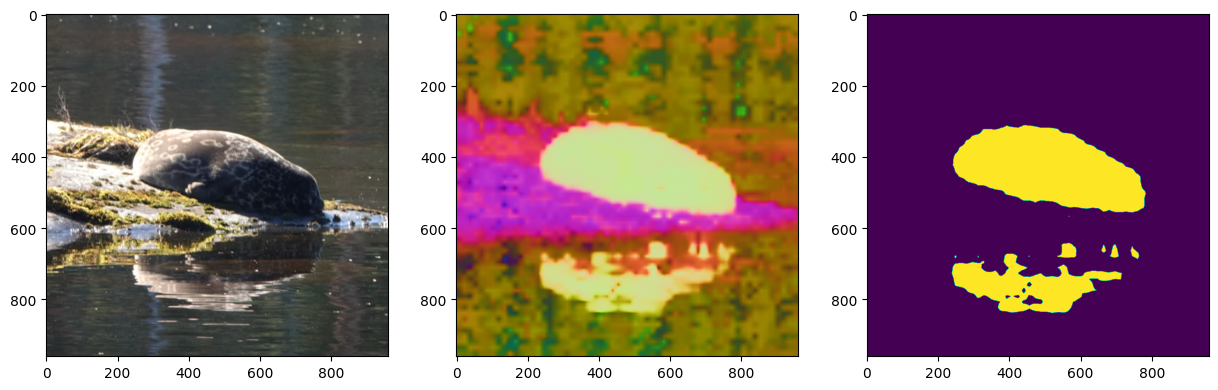

In [42]:
ix = 3
img = resize(Image.open(database_imgs[ix]), 960, edge=False)
sample = all_features[ix]
sample = F.interpolate(sample, 960, mode='bilinear')
sample = normalize(sample)
print(sample.shape)
out = pca.transform(sample.squeeze(0).flatten(1).t())
canvas = out.reshape(960, 960, 3)
canvas = normalize(canvas, dim=2)
canvas = (canvas - canvas.min()) / (canvas.max() - canvas.min())

_, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img)
ax[1].imshow(canvas.cpu())
ax[2].imshow(canvas.cpu()[:, :, 1] > 0.78)